# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

We use those in analysis because we can mangage complex feature spaces and manage that regular linear regression cannot model like binary variables.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross enthropy work well because they compare predicted probabilities to the true classes and penalize wrong confident predictions.

3. True or false, and explain: Logistic regression is a linear model.

True because the predictors are combined linearly before being applied to the logistic function.


4. True or false, and explain: Logistic regression cannot be used for classification.

False because logistic regression is used for classification because of its ability to predict class probabilities that can be converted into labels.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Not necessarily. The coefficient in logistic regression shows the change in the log-odds, not predicted probability for a 1-unit increase in the feature.


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False, feature engineering is important because logistic regression because by creating interaction terms or transformed variables, it can help a model understand more complex relationships.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False, for the most part logistic regression is hlepful when the output is binary or categorical. Otherwise, ordinary least squares still work so it is important to consider the response variable.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [65]:
download_data(force=True)




Download complete
Extracting data files...
Data extracted


'./data'

In [13]:
df = pd.read_csv("data.csv", sep=";")

In [5]:
df = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]].copy()

df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [14]:
df.isna().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


There were no missing values in the selected variables, so no rows were removed.

In [15]:
df["dropout"] = (df["Target"] == "Dropout").astype(int)

df[["Target", "dropout"]].head()
df["dropout"].value_counts()

,count
dropout,
0,3003
1,1421


In [16]:
X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]

y = df["dropout"]

In [17]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

LogisticRegression(max_iter=5000)

In [18]:
import pandas as pd

pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": logit.coef_[0]
})

,Variable,Coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


Being on time and up to date with tuition fees shows the most LEAST likelihood/probability of dropping out and is the lowest dropout probability variable. The hightest however is being in debt.

In [19]:
df["p_logit"] = logit.predict_proba(X)[:, 1]

df[["Age at enrollment", "Tuition fees up to date", "p_logit"]].head()

,Age at enrollment,Tuition fees up to date,p_logit
0,20,1,0.254958
1,19,0,0.807567
2,19,0,0.807567
3,20,1,0.254958
4,45,1,0.543836


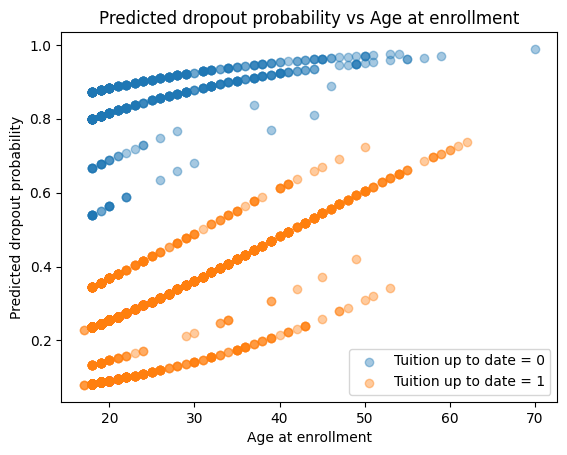

In [20]:
for status in [0, 1]:
    temp = df[df["Tuition fees up to date"] == status]
    plt.scatter(
        temp["Age at enrollment"],
        temp["p_logit"],
        alpha=0.4,
        label=f"Tuition up to date = {status}"
    )

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs Age at enrollment")
plt.legend()
plt.show()

In [21]:
avg_gap = (df[df["Tuition fees up to date"] == 0]["p_logit"].mean()
           - df[df["Tuition fees up to date"] == 1]["p_logit"].mean())

avg_gap

np.float64(0.6125849339840048)

Between the ages of 19-25, it seems that being up to date on tuition reduces dropout probability the most. On average, being up to date on tuition decreases drop out probability by 61 percent as well.

In [22]:
y_pred = logit.predict(X)

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y, y_pred)
cm

pd.DataFrame(
    cm,
    index=["Actual not dropout", "Actual dropout"],
    columns=["Predicted not dropout", "Predicted dropout"]
)

,Predicted not dropout,Predicted dropout
Actual not dropout,2841,162
Actual dropout,891,530


In [25]:
acc = accuracy_score(y, y_pred)
acc

acc * 100

76.19801084990958

The accuracy of correctly predicted dropout is the smallest, and correctly predicted not dropout is the largest number. The overall accuracy is 76% of the classifier.

In [26]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

LinearRegression()

In [29]:
df["p_linear"] = lin.predict(X)
df[["p_logit", "p_linear"]].head()
df["p_linear"].min(), df["p_linear"].max()

(0.05832035022573856, 1.3349535706758708)

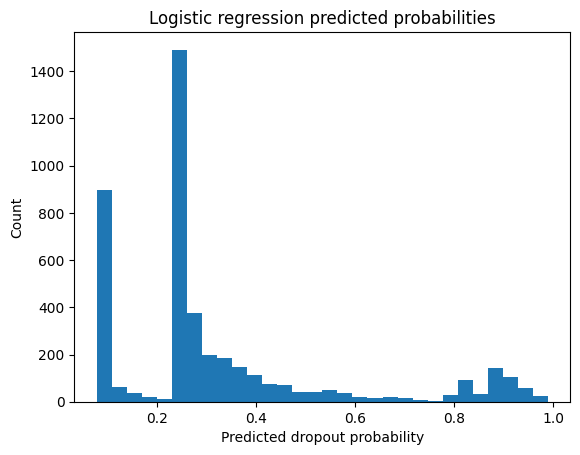

In [30]:
plt.hist(df["p_logit"], bins=30)
plt.xlabel("Predicted dropout probability")
plt.ylabel("Count")
plt.title("Logistic regression predicted probabilities")
plt.show()

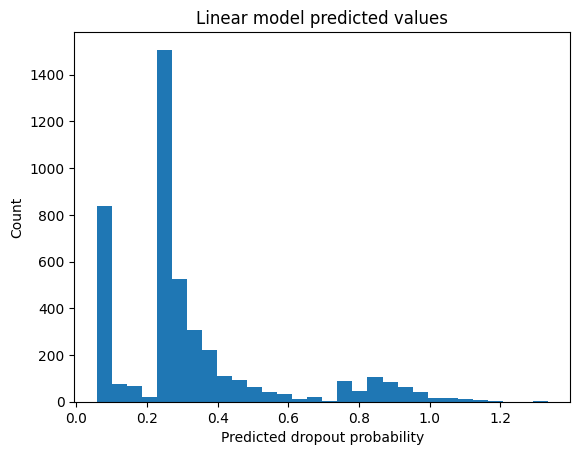

In [31]:
plt.hist(df["p_linear"], bins=30)
plt.xlabel("Predicted dropout probability")
plt.ylabel("Count")
plt.title("Linear model predicted values")
plt.show()

Logistic regression performs better conceptually because it keeps all predicted dropout probabilities between 0 and 1. The linear model produced some predicted values above 1, which shows one weakness of using ordinary least squares for a binary outcome. Since dropout status is either yes or no, logistic regression is the more appropriate model even if the distributions of predicted values look somewhat similar.

In [34]:
df.sort_values("p_logit", ascending=False).head(10)
df.sort_values("p_logit", ascending=False)[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "p_logit"
]].head(10)

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,p_logit
689,1,0,0,70,0.989133
2876,1,0,0,54,0.976161
717,1,0,0,53,0.974971
1887,1,0,0,51,0.972415
3472,1,0,0,50,0.971044
678,1,0,0,50,0.971044
709,1,0,0,50,0.971044
3526,1,0,0,49,0.969607
3281,0,0,0,59,0.968668
4260,1,0,0,48,0.968100


Students with the highest dropout probability are those in debt, not up to date with their tuition payments and not on/have access to scholarships. Some interventions that could applied are increasing financial aid at admittance to university and creating a more sustainable payment plan that allows students to not completely fall into debt.

In [39]:
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]

y_multi = df["Target"]

In [43]:
from sklearn.linear_model import LogisticRegression

multi = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000
)

multi.fit(X_multi, y_multi)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='multinomial')

In [44]:
y_multi_pred = multi.predict(X_multi)

pd.DataFrame({
    "Actual": y_multi,
    "Predicted": y_multi_pred
}).head(10)

,Actual,Predicted
0,Dropout,Dropout
1,Graduate,Dropout
2,Dropout,Dropout
3,Graduate,Graduate
4,Graduate,Graduate
5,Graduate,Graduate
6,Graduate,Graduate
7,Dropout,Dropout
8,Graduate,Graduate
9,Dropout,Dropout


In [45]:
from sklearn.metrics import confusion_matrix

cm_multi = confusion_matrix(y_multi, y_multi_pred, labels=multi.classes_)

pd.DataFrame(
    cm_multi,
    index=[f"Actual {c}" for c in multi.classes_],
    columns=[f"Predicted {c}" for c in multi.classes_]
)

,Predicted Dropout,Predicted Enrolled,Predicted Graduate
Actual Dropout,1054,0,367
Actual Enrolled,280,0,514
Actual Graduate,146,0,2063


The multinomial logistic regression seems to perform strongest for the Graduate class, since it correctly predicts 2063 graduates. However, the model does not predict the enrolled class since the entire predicted enrolled column is zero- meaning enrolled students might be misclassified.

In [47]:
probs_multi = multi.predict_proba(X_multi)

probs_df = pd.DataFrame(probs_multi, columns=multi.classes_)
probs_df.head(10)

,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104
5,0.308421,0.323433,0.368146
6,0.071938,0.140644,0.787418
7,0.952988,0.041199,0.005813
8,0.117808,0.176983,0.705209
9,0.838886,0.122977,0.038136


Yes my hard classification predict every class because it reports every status even when the hard classifier doesn't choose every class.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [72]:
df = pd.read_csv("cirrhosis.csv")

In [79]:
df = df[[
    "Bilirubin",
    "Edema",
    "Drug",
    "Stage",
    "Status"
]].copy()

df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [80]:
df.isna().sum()


,0
Bilirubin,0
Edema,0
Drug,0
Stage,0
Status,0


There are no missing values in the variables used which is good for no observations were removed.

In [82]:
df["survive"] = df["Status"].isin(["C", "CL"]).astype(int)

X = pd.get_dummies(
    df[["Edema", "Drug", "Bilirubin"]],
    drop_first=True
)

y = df["survive"]

In [83]:
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

LogisticRegression(max_iter=5000)

In [84]:
coef_table = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": logit.coef_[0]
})

coef_table

,Variable,Coefficient
0,Bilirubin,-0.351424
1,Edema_S,-0.450677
2,Edema_Y,-1.611049
3,Drug_Placebo,0.231225


The logistic regression suggests that the drug does not improve survival probability. Higher bilirubin predicts a lower survival rate, which is consistent with worse liver function lowering long-term survival chances. Survival also decreases as edema severity increases, with persistent edema (Edema_Y) showing the strongest negative relationship with survival.

In [86]:
df["p_logit"] = logit.predict_proba(X)[:, 1]
df[["Bilirubin", "Drug", "p_logit"]].head()

,Bilirubin,Drug,p_logit
0,14.5,D-penicillamine,0.004836
1,1.1,D-penicillamine,0.729732
2,1.4,D-penicillamine,0.607582
3,1.8,D-penicillamine,0.573608
4,3.4,Placebo,0.602576


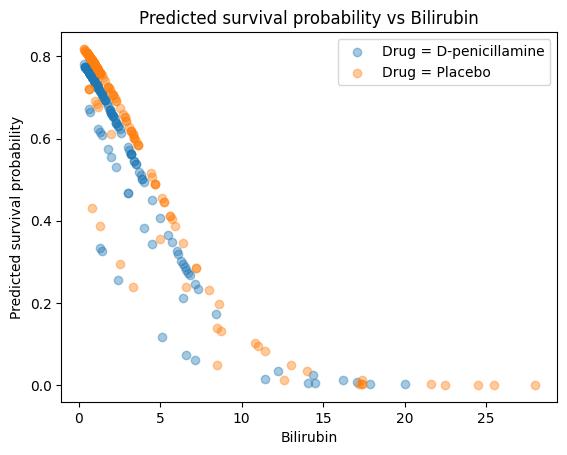

In [87]:
for group in df["Drug"].unique():
    temp = df[df["Drug"] == group]
    plt.scatter(
        temp["Bilirubin"],
        temp["p_logit"],
        alpha=0.4,
        label=f"Drug = {group}"
    )

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs Bilirubin")
plt.legend()
plt.show()

The drug does not show a clear increase survival probability at any major bilirubin range. Bilirubin values between 0 and 8, the placebo group tends to have slightly higher predicted survival probabilities.On average, the drug seems to slightly decrease rather than increase the probability of survival.

In [90]:
y_pred = logit.predict(X)

from sklearn.metrics import confusion_matrix, accuracy_score

cm = confusion_matrix(y, y_pred)

pd.DataFrame(
    cm,
    index=["Actual dead", "Actual alive"],
    columns=["Predicted dead", "Predicted alive"]

)

acc = accuracy_score(y, y_pred)
acc

0.7371794871794872

The accuracy is 73% of classifying patients.

In [94]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df["p_linear"] = lin.predict(X)
df[["p_logit", "p_linear"]].head()

,p_logit,p_linear
0,0.004836,-0.179839
1,0.729732,0.691974
2,0.607582,0.561373
3,0.573608,0.545746
4,0.602576,0.652758


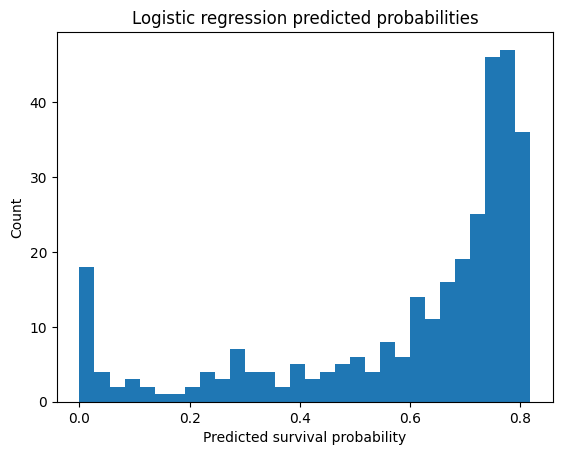

In [95]:
plt.hist(df["p_logit"], bins=30)
plt.xlabel("Predicted survival probability")
plt.ylabel("Count")
plt.title("Logistic regression predicted probabilities")
plt.show()

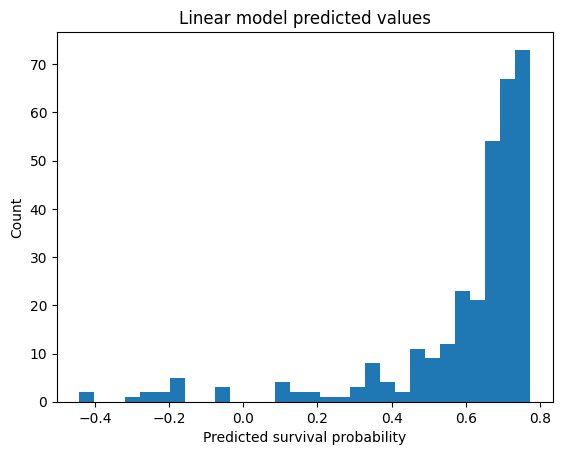

In [96]:
plt.hist(df["p_linear"], bins=30)
plt.xlabel("Predicted survival probability")
plt.ylabel("Count")
plt.title("Linear model predicted values")
plt.show()

In [97]:
df["p_linear"].min(), df["p_linear"].max()

(-0.4417396683935991, 0.7738680250928711)

Logistic regression is more appropriate for this problem because its predicted survival probabilities stay within the valid range of 0 to 1, while the linear model produces impossible values outside that range. In this case, the linear model had a minimum predicted value of about -0.44, which is not a valid probability. The histograms also show that while both models produce a similar general shape, the logistic regression probabilities remain bounded, whereas the linear model spreads into negative values. Because survival status is binary, logistic regression is the better model even if the overall distribution shapes are somewhat similar.

In [98]:
X_stage = pd.get_dummies(
    df[["Edema", "Bilirubin"]],
    drop_first=True
)

y_stage = df["Stage"]

In [100]:
from sklearn.linear_model import LogisticRegression

stage_model = LogisticRegression(
    multi_class="multinomial",
    max_iter=5000
)

stage_model.fit(X_stage, y_stage)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [101]:
y_stage_pred = stage_model.predict(X_stage)

In [102]:
from sklearn.metrics import confusion_matrix

cm_stage = confusion_matrix(
    y_stage,
    y_stage_pred,
    labels=stage_model.classes_
)

pd.DataFrame(
    cm_stage,
    index=[f"Actual Stage {c}" for c in stage_model.classes_],
    columns=[f"Predicted Stage {c}" for c in stage_model.classes_]
)

,Predicted Stage 1.0,Predicted Stage 2.0,Predicted Stage 3.0,Predicted Stage 4.0
Actual Stage 1.0,0,0,16,0
Actual Stage 2.0,0,0,63,4
Actual Stage 3.0,0,0,105,15
Actual Stage 4.0,0,0,79,30


The multinomial logistic regression mainly predicts Stage 3 and Stage 4, and does not predict Stage 1 or Stage 2 at all. It performs best for Stage 3, while many patients in other stages are misclassified as Stage 3. This highlights that edema and bilirubin alone are not enough to clearly separate the earlier disease stages.

In [103]:
stage_probs = stage_model.predict_proba(X_stage)

stage_probs_df = pd.DataFrame(
    stage_probs,
    columns=stage_model.classes_
)

stage_probs_df.head(10)

,1.0,2.0,3.0,4.0
0,0.000013,0.032535,0.143611,0.823841
1,0.072394,0.251555,0.397520,0.278531
2,0.029263,0.181531,0.395694,0.393512
3,0.023272,0.176777,0.397217,0.402734
4,0.020204,0.224965,0.423342,0.331488
5,0.084886,0.253397,0.391412,0.270305
6,0.076359,0.252233,0.395575,0.275833
7,0.110046,0.255032,0.379260,0.255662
8,0.022637,0.227782,0.422181,0.327400
9,0.000042,0.040292,0.153955,0.805712


In [104]:
pd.Series(y_stage_pred).value_counts()

,count
3.0,263
4.0,49


No, hard classification does not predict every class and yes predicted probabilities predict every class/all four stages, since it gives a probability for each possible stage for every patient.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

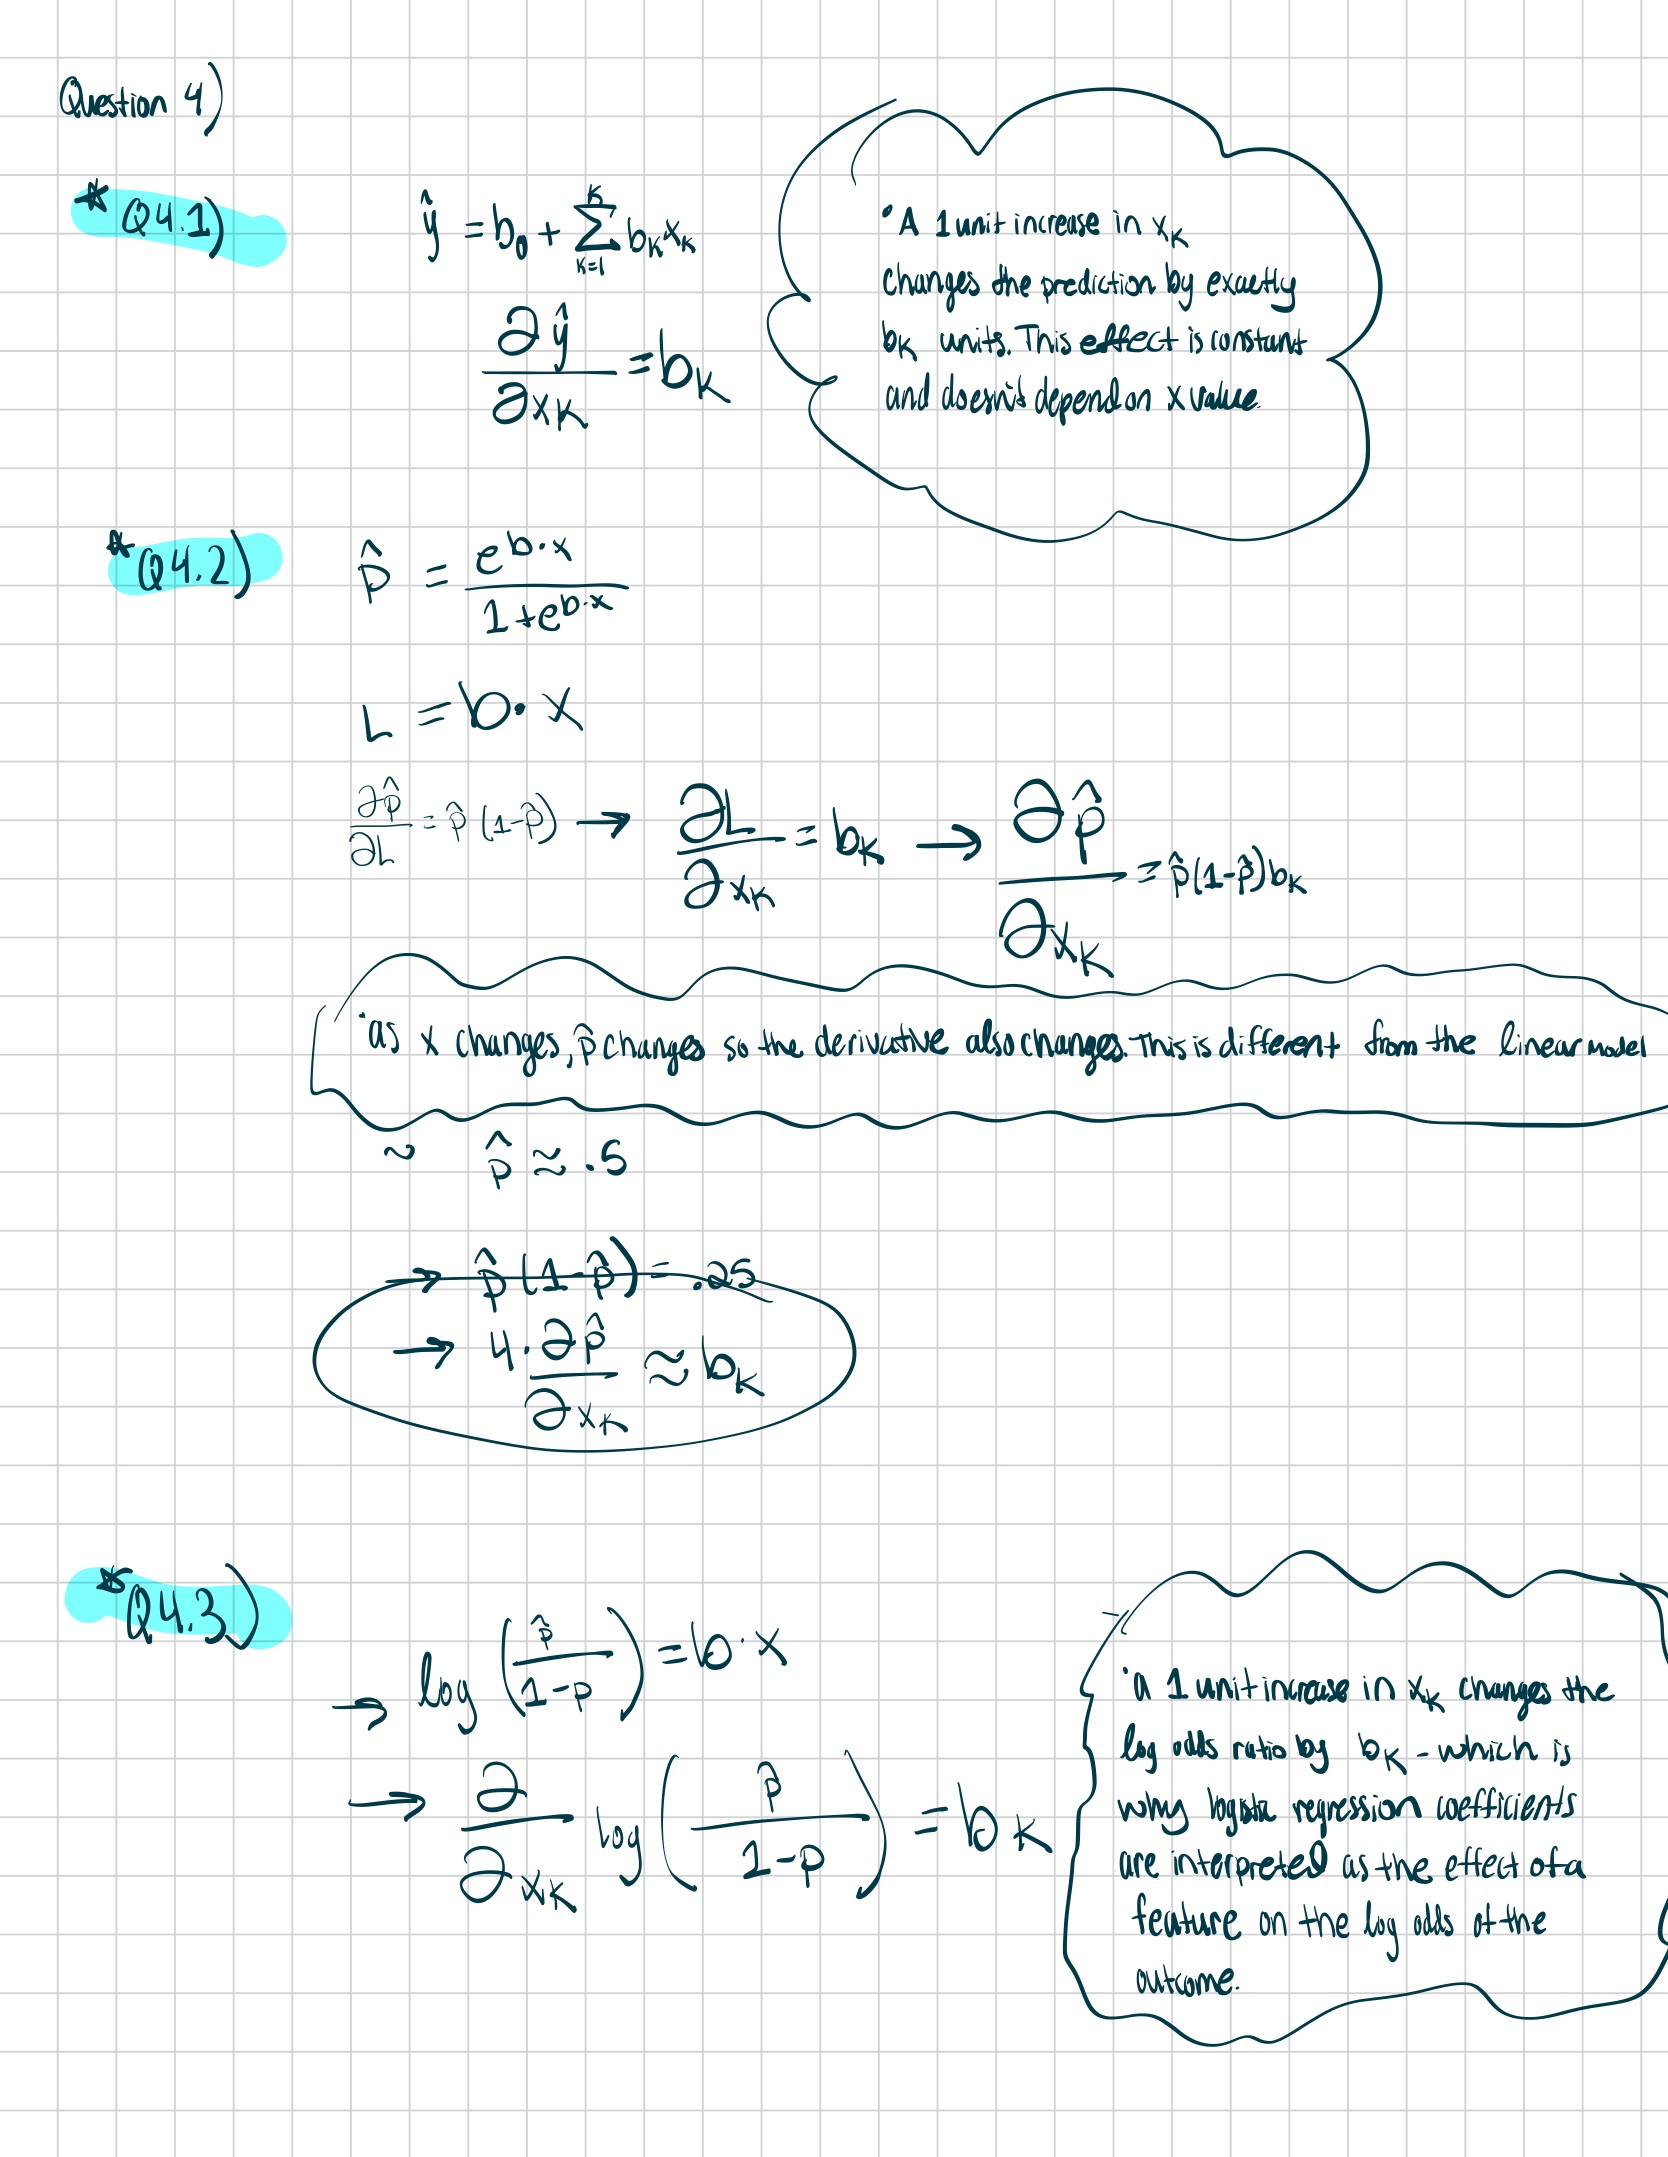